# CPA attack on unmasked MAYO

<div class="alert" style="background-color: #FFE9C7; color: #3f2a0a; border: 1px solid #ffe0b2; font-size: 15px;">
<strong>Notebook overview:</strong> This notebook performs a CPA attack on the unmasked, nibble-sliced MAYO implementation. 
The target function is <code>P1P1t_times_O</code>, using pre-captured traces and call indices from <code>01_capture_mayo1_stm32f4.ipynb</code>.
<br><br>
<font color='maroon'>→ Target:</font> unmasked, nibble-sliced MAYO</br>
<font color='maroon'>→ Target function:</font> <code>P1P1t_times_O</code></br>
<font color='maroon'>→ Input:</font> Raw or averaged power trace and precomputed peak indices</br>
<font color='maroon'>→ Goal:</font> Recover the oil matrix using CPA</br>
</div>

In [1]:
from pathlib import Path
import sys
import numpy as np

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "data"

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import chipwhisperer as cw
import matplotlib.pyplot as plt

### Load data

In [6]:
from data.data import attack_O, attack_P2, attack_P1
data_raw_trace = np.load(DATA_DIR / "data_raw.npy")
data_5_avg = np.load(DATA_DIR / "5_avg_data.npy")
data_10_avg = np.load(DATA_DIR / "10_avg_data.npy")

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Input trace:</strong> This unmasked attack may be run on an averaged trace to reduce noise. 
Set <code>input_trace</code> to the trace that should be analyzed.
</div>

In [3]:
input_trace = data_5_avg

### Precalculated segment size pattern from average trace

In [7]:
peaks = np.load(DATA_DIR/"peaks_unmasked.npy")

## Trace Segmentation

In [5]:
def oil_segment_indices(z, k, v=78, o=8):
    assert 0 <= z < v
    assert 0 <= k < o

    result = []

    for r in range(z):
        result.append(call_idx(r, z, k, which=0, v=v))

    for c in range(z + 1, v):
        result.append(call_idx(z, c, k, which=1, v=v))

    result.sort()
    return result

def call_idx(r, c, k, which, v=78):
    p = pair_idx(r, c, v)
    return 16 * p + 2 * k + which

def pair_idx(r, c, v=78):
    assert 0 <= r < c < v
    return r * (2 * v - r - 1) // 2 + (c - r - 1)

def build_segment_records(full_trace, peaks):
    peaks = np.asarray(peaks, dtype=int)
    peaks = np.sort(peaks)

    records = []

    for i in range(len(peaks) - 1):
        s = int(peaks[i])
        e = int(peaks[i + 1])

        records.append({
            "global_idx": i,
            "start": s,
            "end": e,
            "length": e - s,
            "segment": np.asarray(full_trace[s:e], dtype=float),
        })

    if len(peaks) > 0 and peaks[-1] < len(full_trace):
        s = int(peaks[-1])
        e = int(len(full_trace))

        records.append({
            "global_idx": len(records),
            "start": s,
            "end": e,
            "length": e - s,
            "segment": np.asarray(full_trace[s:e], dtype=float),
        })

    return records

def get_oil_segment_records(segment_records, z, k, v=78, o=8):
    idxs = oil_segment_indices(z, k, v=v, o=o) 

    record_map = {rec["global_idx"]: rec for rec in segment_records}

    selected = []
    for idx in idxs:
        if idx in record_map:
            selected.append(record_map[idx].copy())

    return selected

def merge_oil_segments(oil_records, allowed_lengths=None, target_len=None):
    selected = []

    for rec in oil_records:
        L = rec["length"]
        if allowed_lengths is not None and L not in allowed_lengths:
            continue
        selected.append(np.asarray(rec["segment"], dtype=float))

    if len(selected) == 0:
        return np.empty((0, 0), dtype=float)

    if target_len is None:
        target_len = min(len(seg) for seg in selected)

    merged = []
    for seg in selected:
        if len(seg) >= target_len:
            merged.append(seg[:target_len])

    if len(merged) == 0:
        return np.empty((0, 0), dtype=float)

    return np.asarray(merged, dtype=float)

## Precalculations

In [6]:
v = 78
o = 8
O = attack_O
limbs = 5

In [7]:
segment_records = build_segment_records(input_trace, peaks)

In [8]:
acc_state = np.array(attack_P2, dtype=np.uint64).reshape(v, o, limbs).copy()

In [9]:
def upper_tri_bs_index(r, c, v):
    assert 0 <= r <= c < v
    bs = 0
    for rr in range(r):
        bs += v - rr
    bs += (c - r)
    return bs

def get_P1_block(attack_P1, r, c, limbs, v):
    bs = upper_tri_bs_index(r, c, v)
    return extract_p1_entry_by_bs(attack_P1, limbs, bs)

def extract_p1_entry_by_bs(attack_P1, limbs, bs):
    start = bs * limbs
    end = start + limbs
    return np.array(attack_P1[start:end], dtype=np.uint64)


def get_entries_for_coeff(acc_state, attack_P1, v, o, limbs, z, k0):
    dest_rows = []
    p1_blocks = []
    acc_init_blocks = []

    for row in range(v):
        if row == z:
            continue

        r0 = min(z, row)
        c0 = max(z, row)

        p1_block = get_P1_block(attack_P1, r0, c0, limbs, v)
        acc_block = acc_state[row, k0, :].copy()

        dest_rows.append(row)
        p1_blocks.append(p1_block)
        acc_init_blocks.append(acc_block)

    P1_entries = np.array(p1_blocks, dtype=np.uint64)
    acc_init = np.array(acc_init_blocks, dtype=np.uint64)

    return dest_rows, P1_entries, acc_init

### Overlay of all oil segments for one coefficient

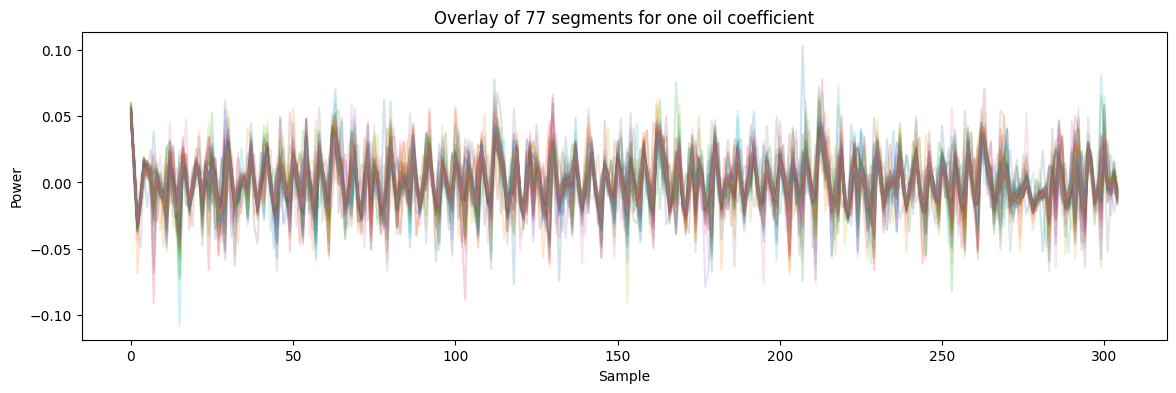

In [10]:
oil_records_for_coeff = get_oil_segment_records(segment_records, z=0, k=0, v=78, o=8)
merged_oil_segments = merge_oil_segments(oil_records_for_coeff, target_len=305)

plt.figure(figsize=(14,4))
for seg in merged_oil_segments:
    x = seg - np.mean(seg)
    plt.plot(x, alpha=0.2)
plt.title("Overlay of 77 segments for one oil coefficient")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.grid(False)
plt.show()

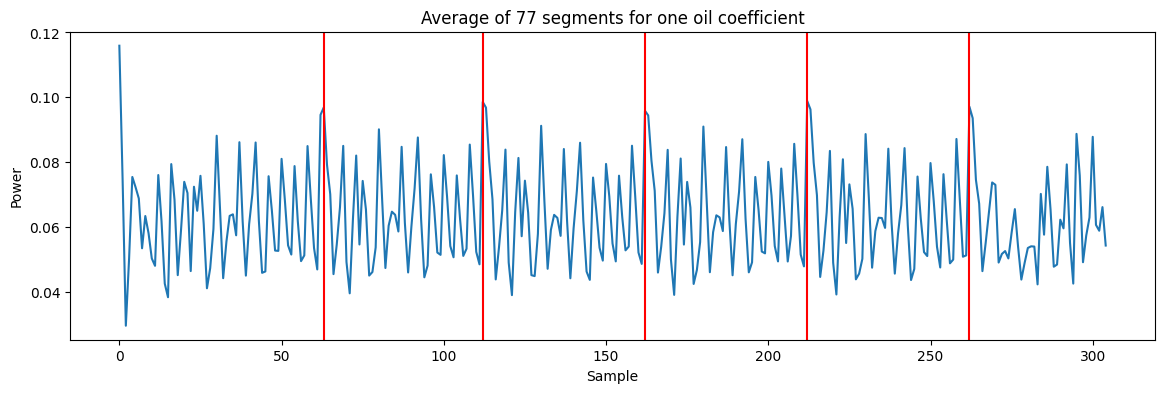

In [11]:
from scipy.signal import find_peaks
seg = np.mean(np.asarray(merged_oil_segments, dtype=float), axis=0)

peakstest, props = find_peaks(
    seg,
    height=0.08,
    distance=49
)

plt.figure(figsize=(14, 4))
plt.plot(seg)

for p in peakstest:
    plt.axvline(p, color='red')
plt.title("Average of 77 segments for one oil coefficient")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.show()

## Correlation Power Analysis

### Leakage Modeling

In [12]:
def hw(x):
    return bin(int(x)).count("1")

LSB_MASK = 0x1111111111111111

def mul_table(b):
    b = int(b) & 0x0F
    x = (b * 0x08040201) & 0xffffffff
    high = x & 0xf0f0f0f0
    return (x ^ (high >> 4) ^ (high >> 3)) & 0xffffffff


def m_vec_mul_add_model(in_vec, a, acc):
    in_vec = np.array(in_vec, dtype=np.uint64)
    acc = np.array(acc, dtype=np.uint64).copy()
    tab = mul_table(a)

    for i, val in enumerate(in_vec):
        val = int(val)

        v = (
            ((val & LSB_MASK) * (tab & 0xff))
            ^ (((val >> 1) & LSB_MASK) * ((tab >> 8) & 0xf))
            ^ (((val >> 2) & LSB_MASK) * ((tab >> 16) & 0xf))
            ^ (((val >> 3) & LSB_MASK) * ((tab >> 24) & 0xf))
        ) & 0xffffffffffffffff

        acc[i] ^= np.uint64(v)

    return acc

def build_hypothesis_hw(P1_entries, acc_init, limbs=5):
    NUM_KEYS = 16
    N = P1_entries.shape[0]   

    hyp = np.zeros((NUM_KEYS, N * limbs), dtype=float)

    for k in range(NUM_KEYS):
        idx = 0
        for i in range(N):
            p1 = np.array(P1_entries[i], dtype=np.uint64)
            acc_before = np.array(acc_init[i], dtype=np.uint64)

            acc_after = m_vec_mul_add_model(p1, k, acc_before.copy())

            for limb in range(limbs):
                hyp[k, idx] = hw(int(acc_after[limb]) & 0xffffffff)
                idx += 1

    return hyp

### Correlation

In [13]:
def normalize_limbs(x, limbs):
    x = np.array(x, dtype=float).copy()
    for i in range(limbs):
        xi = x[i::limbs]
        xi -= np.mean(xi)
        s = np.std(xi)
        if s > 1e-12:
            xi /= s
        x[i::limbs] = xi
    return x


def run_cpa(power, hyp, limbs):
    power = normalize_limbs(power, limbs)
    corr = np.zeros(hyp.shape[0])

    for k in range(hyp.shape[0]):
        h = normalize_limbs(hyp[k], limbs)
        if np.std(power) < 1e-12 or np.std(h) < 1e-12:
            continue
        c = np.corrcoef(power, h)[0, 1]
        if not np.isnan(c):
            corr[k] = c
    return corr

In [14]:
def recover_oil(
    segment_records,
    acc_state,
    attack_P1,
    v,
    o,
    limbs,
    z,
    k,
    poi_list,
    target_len=305,
):

    if len(poi_list) != limbs:
        raise ValueError(f"poi_list must have length {limbs}")

    oil_records = get_oil_segment_records(segment_records, z, k, v=v, o=o)
    segments = merge_oil_segments(
        oil_records,
        allowed_lengths=(305, 309, 328, 348, 334),
        target_len=target_len,
    )
    segments = np.asarray(segments, dtype=float)

    if len(segments) == 0:
        raise ValueError(f"No segments found for z={z}, k={k}")

    _, p1, acc_init = get_entries_for_coeff(
        acc_state=acc_state,
        attack_P1=attack_P1,
        v=v,
        o=o,
        limbs=limbs,
        z=z,
        k0=k,
    )

    if len(segments) != len(p1) or len(segments) != len(acc_init):
        raise ValueError(
            f"Mismatch: segments={len(segments)}, p1={len(p1)}, acc_init={len(acc_init)}"
        )

    hyp = build_hypothesis_hw(p1, acc_init, limbs=limbs)

    power_parts = []
    poi_lists = []

    for i in range(limbs):
        poi = int(poi_list[i])

        if poi < 0 or poi >= segments.shape[1]:
            raise ValueError(
                f"POI {poi} for limb {i} is outside the segment length {segments.shape[1]}"
            )

        poi_lists.append(np.array([poi], dtype=np.int64))

        p = segments[:, poi]
        p = (p - np.mean(p)) / (np.std(p) + 1e-12)
        power_parts.append(p)

    N = len(power_parts[0])
    power = np.empty(limbs * N)

    for i in range(limbs):
        power[i::limbs] = power_parts[i]

    corr = run_cpa(power, hyp, limbs)
    guess = int(np.argmax(np.abs(corr)))

    debug = {
        "poi_list": poi_list,
        "segments_shape": segments.shape,
    }

    return guess, corr, poi_lists, power, hyp, debug

## CPA on one oil coefficient

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Single-coefficient CPA:</strong> The column <code>k</code> can be changed to test a different oil-column coefficient. 
For this single-coefficient test, keep <code>z = 0</code> since the attack is evaluated for row 0.
</div>

Recovered oil coefficient: 12
0 -0.0262184953789871
1 0.10884552770608631
2 -0.05461954848155633
3 0.03501382398252115
4 -0.0015989827974938876
5 -0.03135400379497768
6 0.02934219741470315
7 0.008258570776944262
8 0.06626054586595027
9 0.025412732775583848
10 -0.11406655530624475
11 -0.08261523855227824
12 0.5011643241684212
13 -0.06640446329150093
14 0.09460619391579755
15 -0.01902095923774124


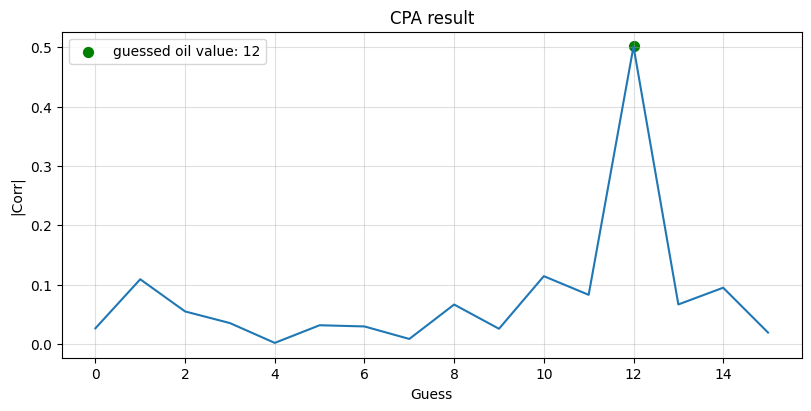

In [15]:
guess, corr, poi_lists, power, hyp, debug = recover_oil(
    segment_records=segment_records,
    acc_state=acc_state,
    attack_P1=attack_P1,
    v=v,
    o=o,
    limbs=limbs,
    z=0,
    k=5,
    poi_list=[63, 113, 163, 213, 263],
    target_len=305,
)

print("Recovered oil coefficient:", guess)

for i, c in enumerate(corr):
    print(i, c)

y = np.abs(corr)
max_idx = np.argmax(y)
max_val = y[max_idx]

plt.figure(figsize=(8, 4), constrained_layout=True)
plt.plot(range(16), y)  
plt.scatter(max_idx, max_val, color='green', s=50, label="guessed oil value: " + str(guess))
plt.xlabel("Guess")
plt.ylabel("|Corr|")

plt.xticks()
plt.yticks()

plt.title("CPA result")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

## CPA on one oil vector

In [16]:
def update_acc_for_coeff(acc_state, guessed_coeff, z, k0, attack_P1, v, limbs):
    for c in range(v):
        if c == z:
            continue

        r0 = min(z, c)
        c0 = max(z, c)
        p1_block = get_P1_block(attack_P1, r0, c0, limbs, v)

        acc_before = acc_state[c, k0, :].copy()
        acc_after = m_vec_mul_add_model(p1_block, guessed_coeff, acc_before)
        acc_state[c, k0, :] = acc_after

    return acc_state

In [17]:
acc_state_init = np.array(attack_P2, dtype=np.uint64).reshape(v, o, limbs).copy()

In [18]:
import numpy as np

def recover_oil_vector(
    column,
    segment_records,
    acc_state,
    attack_P1,
    v,
    o,
    limbs,
    poi_list,
    num_rows=None,
    ambiguity_margin=0.35,
    lookahead_top_k=2,
    target_len=305,
):
    lookahead_count = 0

    if num_rows is None:
        num_rows = v

    recovered_vector = []
    margins = []

    def analyze_row(acc_state_local, row_idx):
        guess, corr, poi_lists, power, hyp, debug = recover_oil(
            segment_records=segment_records,
            acc_state=acc_state_local,
            attack_P1=attack_P1,
            v=v,
            o=o,
            limbs=limbs,
            z=row_idx,
            k=column,
            poi_list=poi_list,
            target_len=target_len,
        )

        abs_corr = np.abs(corr)
        winner_corr = corr[guess]

        masked = np.array(abs_corr, copy=True)
        masked[guess] = -np.inf

        next_best_guess = int(np.argmax(masked))
        next_best_corr = corr[next_best_guess]
        margin = abs_corr[guess] - abs_corr[next_best_guess]

        return {
            "guess": guess,
            "corr": corr,
            "winner_corr": winner_corr,
            "next_best_guess": next_best_guess,
            "next_best_corr": next_best_corr,
            "margin": margin,
            "debug": debug,
            "poi_lists": poi_lists,
            "power": power,
            "hyp": hyp,
        }

    for row in range(num_rows):
        analysis = analyze_row(acc_state, row)

        local_best = analysis["guess"]
        corr = analysis["corr"]
        local_winner_corr = analysis["winner_corr"]
        local_next_best_guess = analysis["next_best_guess"]
        local_next_best_corr = analysis["next_best_corr"]
        local_margin = analysis["margin"]

        final_guess = local_best
        final_winner_corr = local_winner_corr
        final_next_best_guess = local_next_best_guess
        final_next_best_corr = local_next_best_corr
        final_margin = local_margin

        used_lookahead = False
        lookahead_details = None

        if row + 1 < num_rows and local_margin < ambiguity_margin:
            used_lookahead = True
            lookahead_count += 1

            abs_corr = np.abs(corr)
            top_candidates = np.argsort(abs_corr)[-lookahead_top_k:][::-1]

            best_candidate = None
            best_total_score = -np.inf
            best_info = None
            candidate_infos = []

            for cand in top_candidates:
                cand = int(cand)

                current_abs = np.abs(corr)
                current_corr = corr[cand]

                masked = np.array(current_abs, copy=True)
                masked[cand] = -np.inf

                current_next_best_guess = int(np.argmax(masked))
                current_next_best_corr = corr[current_next_best_guess]
                current_margin = current_abs[cand] - current_abs[current_next_best_guess]

                candidate_acc_state = update_acc_for_coeff(
                    acc_state=acc_state.copy(),
                    guessed_coeff=cand,
                    attack_P1=attack_P1,
                    v=v,
                    limbs=limbs,
                    z=row,
                    k0=column,
                )

                next_analysis = analyze_row(candidate_acc_state, row + 1)

                next_guess = next_analysis["guess"]
                next_winner_corr = next_analysis["winner_corr"]
                next_margin = next_analysis["margin"]

                total_score = (
                    np.abs(current_corr)
                    + current_margin
                    + np.abs(next_winner_corr)
                    + next_margin
                )

                info = {
                    "candidate": cand,
                    "current_corr": current_corr,
                    "current_margin": current_margin,
                    "next_guess": next_guess,
                    "next_winner_corr": next_winner_corr,
                    "next_margin": next_margin,
                    "total_score": total_score,
                }
                candidate_infos.append(info)

                if total_score > best_total_score:
                    best_total_score = total_score
                    best_candidate = cand
                    best_info = info

            final_guess = best_candidate
            final_winner_corr = corr[final_guess]

            abs_corr = np.abs(corr)
            masked = np.array(abs_corr, copy=True)
            masked[final_guess] = -np.inf

            final_next_best_guess = int(np.argmax(masked))
            final_next_best_corr = corr[final_next_best_guess]
            final_margin = abs_corr[final_guess] - abs_corr[final_next_best_guess]

            lookahead_details = {
                "candidates": candidate_infos,
                "chosen": best_info,
            }

        recovered_vector.append(final_guess)
        margins.append(final_margin)


        print(
            f"row={row:2d}, "
            f"local_best={local_best}, final_guess={final_guess}, "
            f"local_corr={local_winner_corr:.6f}, "
            f"next_best_guess={local_next_best_guess}, "
            f"next_best_corr={local_next_best_corr:.6f}, "
            f"local_margin={local_margin:.6f}, "
            f"{'LOOKAHEAD' if used_lookahead else 'DIRECT'}"
        )

        if used_lookahead and lookahead_details is not None:
            print("    lookahead candidates:")
            for info in lookahead_details["candidates"]:
                print(
                    f"      cand={info['candidate']}, "
                    f"curr_corr={info['current_corr']:.6f}, "
                    f"curr_margin={info['current_margin']:.6f}, "
                    f"next_guess={info['next_guess']}, "
                    f"next_winner_corr={info['next_winner_corr']:.6f}, "
                    f"next_margin={info['next_margin']:.6f}, "
                    f"total_score={info['total_score']:.6f}"
                )
            chosen = lookahead_details["chosen"]
            print(
                f"    chosen_by_lookahead: cand={chosen['candidate']}, "
                f"next_guess={chosen['next_guess']}, "
                f"total_score={chosen['total_score']:.6f}"
            )

        acc_state = update_acc_for_coeff(
            acc_state=acc_state,
            guessed_coeff=final_guess,
            attack_P1=attack_P1,
            v=v,
            limbs=limbs,
            z=row,
            k0=column,
        )


    print("mean margin:", np.mean(margins))
    print("min margin :", np.min(margins))
    print("max margin :", np.max(margins))
    print("lookahead count: ", lookahead_count)

    return recovered_vector, acc_state

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Oil-vector recovery:</strong> The target column, <code>ambiguity_margin</code>, and <code>lookahead_top_k</code> can be adjusted below. 
Lowering <code>ambiguity_margin</code> makes lookahead less frequent, while increasing <code>lookahead_top_k</code> evaluates more candidate guesses when the margin is low.
</div>

In [ ]:
column = 0
oil_vector, acc_after = recover_oil_vector(
    column=column,
    segment_records=segment_records,
    acc_state=acc_state_init.copy(),
    attack_P1=attack_P1,
    v=v,
    o=o,
    limbs=limbs,
    poi_list=[63, 113, 163, 213, 263],
    ambiguity_margin=0.25,
    lookahead_top_k=3,
    target_len=305,
)

In [20]:
from IPython.display import display, HTML
import numpy as np

def check_oil_vector(recovered_vector, true_O, column, o=8):
    true_vector = np.array(true_O).reshape(-1, o)[:, column]
    recovered_vector = np.array(recovered_vector)
    true_vector = true_vector[:len(recovered_vector)]

    print("Recovered:", recovered_vector)
    print("True     :", true_vector)

    ok = np.all(recovered_vector == true_vector)
    num_correct = np.sum(recovered_vector == true_vector)
    total = len(recovered_vector)

    if ok:
        display(HTML(f"""
        <div class="alert alert-success" style="background-color: #eefaf1; color: #14532d; border-color: #bbf7d0;">
            <strong>RESULT: Match</strong>, oil vector recovered correctly ({num_correct}/{total} correct).
        </div>
        """))
    else:
        display(HTML(f"""
        <div class="alert alert-danger" style="background-color: #fff1f2; color: #7f1d1d; border-color: #fecdd3;">
            <strong>RESULT: Mismatch</strong>, oil vector recovery failed ({num_correct}/{total} correct).
        </div>
        """))
check_oil_vector(oil_vector, attack_O, column)

Recovered: [ 8  5  0  5  0  8 15  8 12  3  7 14  0  7  9 12 13 10 14  4  5  9 11  8
 14  7  1 14  2 11 14  7  8  0  0  1 10  2  3  3 11 13  2  2 14  1 15  8
  2  0  8 15  6 11 10  2  2  1 15  0  7  6  9 10  9  6  9  2  8 13  1  0
  6  7 14  1  8 13]
True     : [ 8  5  0  5  0  8 15  8 12  3  7 14  0  7  9 12 13 10 14  4  5  9 11  8
 14  7  1 14  2 11 14  7  8  0  0  1 10  2  3  3 11 13  2  2 14  1 15  8
  2  0  8 15  6 11 10  2  2  1 15  0  7  6  9 10  9  6  9  2  8 13  1  0
  6  7 14  1  8 13]


## CPA on full oil matrix

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Matrix recovery:</strong> The full oil matrix is recovered column by column. 
The parameters <code>ambiguity_margin</code> and <code>lookahead_top_k</code> can be adjusted in <code>recover_oil_matrix(...)</code> if recovery is unstable.
</div>

In [21]:
import numpy as np

def recover_oil_matrix(
    segment_records,
    acc_state_init,
    attack_P1,
    v,
    o,
    limbs,
    poi_list=None,
    num_rows=None,
    ambiguity_margin=0.25,
    lookahead_top_k=3,
    target_len=305,
):
    if num_rows is None:
        num_rows = v

    acc_state = np.array(acc_state_init, copy=True)
    recovered_O_matrix = np.zeros((num_rows, o), dtype=np.int64)

    for column in range(o):
        print(f"\n===== Recovering column {column} =====")

        oil_vector, acc_state = recover_oil_vector(
            column=column,
            segment_records=segment_records,
            acc_state=acc_state,
            attack_P1=attack_P1,
            v=v,
            o=o,
            limbs=limbs,
            poi_list=poi_list,
            num_rows=num_rows,
            ambiguity_margin=ambiguity_margin,
            lookahead_top_k=lookahead_top_k,
            target_len=target_len,
        )

        recovered_O_matrix[:, column] = np.asarray(oil_vector, dtype=np.int64)

    return recovered_O_matrix, acc_state

In [ ]:
recovered_O_matrix, acc_state_final = recover_oil_matrix(
    segment_records=segment_records,
    acc_state_init=acc_state_init,
    attack_P1=attack_P1,
    v=v,
    o=o,
    limbs=limbs,
    poi_list=[63, 113, 163, 213, 263],
)

In [23]:
from IPython.display import display, HTML
import numpy as np

def check_oil_matrix(recovered_O_matrix, attack_O, v, o):
    true_O_matrix = np.array(attack_O, dtype=np.int64).reshape(v, o)
    recovered_O_matrix = np.array(recovered_O_matrix, dtype=np.int64)

    ok = np.all(recovered_O_matrix == true_O_matrix)
    num_correct = np.sum(recovered_O_matrix == true_O_matrix)
    total = v * o

    if ok:
        display(HTML(f"""
        <div class="alert alert-success" style="background-color: #eefaf1; color: #14532d; border-color: #bbf7d0;">
            <strong>RESULT: Match</strong>, full oil matrix recovered correctly ({num_correct}/{total} correct).
        </div>
        """))
    else:
        display(HTML(f"""
        <div class="alert alert-danger" style="background-color: #fff1f2; color: #7f1d1d; border-color: #fecdd3;">
            <strong>RESULT: Mismatch</strong>, oil matrix recovery failed ({num_correct}/{total} correct).
        </div>
        """))
check_oil_matrix(recovered_O_matrix, attack_O, v, o)